<a href="https://colab.research.google.com/github/OPIM5512-erc25001/A01_5512/blob/main/Weekly_Sales_Forecasting_with_Exponential_Smoothing_(ETS).ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [58]:
from google.colab import drive
drive.mount('/content/drive')
# Now you can access your file at:
# '/content/drive/MyDrive/MSBAPM/Fall 2026/weekly_df_final_for_modeling.csv'

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [59]:
df = pd.read_csv('/content/drive/MyDrive/MSBAPM/Fall 2026/weekly_df_final_for_modeling.csv')

In [60]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from statsmodels.tsa.holtwinters import(SimpleExpSmoothing,Holt,ExponentialSmoothing)
from statsmodels.stats.diagnostic import acorr_ljungbox
from statsmodels.graphics.tsaplots import plot_acf
from statsmodels.tsa.seasonal import seasonal_decompose
from sklearn.metrics import mean_absolute_error, mean_squared_error

In [61]:
print(df.head())

      sku        week   channel      region  units_sold  stock_available  \
0  JU-021  2022-08-08  Discount  PL-Central         130            158.8   
1  JU-021  2022-08-15  Discount  PL-Central          81            149.8   
2  JU-021  2022-08-22  Discount  PL-Central          72            151.5   
3  JU-021  2022-08-29  Discount  PL-Central         125            134.0   
4  JU-021  2022-09-05  Discount  PL-Central         176            176.5   

   promotion_flag  price_unit  delivery_days  is_holiday_peak  ...  is_summer  \
0               1      4.3820       3.000000            False  ...          1   
1               0      7.6140       4.000000            False  ...          1   
2               0      4.1525       2.500000            False  ...          1   
3               1      3.9400       3.166667            False  ...          1   
4               0      5.0300       4.000000            False  ...          0   

   is_winter  sku_age  lifecycle_stage  lag_1  lag_2  ro

In [62]:
print(df.dtypes)

sku                  object
week                 object
channel              object
region               object
units_sold            int64
stock_available     float64
promotion_flag        int64
price_unit          float64
delivery_days       float64
is_holiday_peak        bool
week_number           int64
month                 int64
year                  int64
is_holiday_week       int64
is_summer             int64
is_winter             int64
sku_age               int64
lifecycle_stage      object
lag_1               float64
lag_2               float64
rolling_mean_4      float64
rolling_std_4       float64
momentum            float64
target_next_week    float64
dtype: object


In [63]:
df["week"] = pd.to_datetime(df["week"])
df = df.sort_values("week")
df = df.set_index("week")

In [64]:
df.index

DatetimeIndex(['2022-02-14', '2022-02-14', '2022-02-14', '2022-02-14',
               '2022-02-14', '2022-02-14', '2022-02-14', '2022-02-14',
               '2022-02-14', '2022-02-14',
               ...
               '2024-12-23', '2024-12-23', '2024-12-23', '2024-12-23',
               '2024-12-23', '2024-12-23', '2024-12-23', '2024-12-23',
               '2024-12-23', '2024-12-23'],
              dtype='datetime64[ns]', name='week', length=31027, freq=None)

In [65]:
print(df.head)

<bound method NDFrame.head of                sku     channel      region  units_sold  stock_available  \
week                                                                      
2022-02-14  MI-026      Retail  PL-Central          81       160.750000   
2022-02-14  MI-006    Discount  PL-Central          73       160.333333   
2022-02-14  MI-006    Discount    PL-North          44       134.500000   
2022-02-14  MI-006    Discount    PL-South          83       194.200000   
2022-02-14  MI-026  E-commerce    PL-North          49       108.600000   
...            ...         ...         ...         ...              ...   
2024-12-23  SN-010      Retail  PL-Central          90       136.714286   
2024-12-23  SN-010      Retail    PL-North          93       190.600000   
2024-12-23  SN-010      Retail    PL-South          69       162.500000   
2024-12-23  RE-025      Retail    PL-South         131       175.000000   
2024-12-23  YO-029      Retail    PL-South          98       154.16666

In [66]:
print(df.columns)

Index(['sku', 'channel', 'region', 'units_sold', 'stock_available',
       'promotion_flag', 'price_unit', 'delivery_days', 'is_holiday_peak',
       'week_number', 'month', 'year', 'is_holiday_week', 'is_summer',
       'is_winter', 'sku_age', 'lifecycle_stage', 'lag_1', 'lag_2',
       'rolling_mean_4', 'rolling_std_4', 'momentum', 'target_next_week'],
      dtype='object')


In [67]:
print(df.index.unique())

DatetimeIndex(['2022-02-14', '2022-02-21', '2022-02-28', '2022-03-07',
               '2022-03-14', '2022-03-21', '2022-03-28', '2022-04-04',
               '2022-04-11', '2022-04-18',
               ...
               '2024-10-21', '2024-10-28', '2024-11-04', '2024-11-11',
               '2024-11-18', '2024-11-25', '2024-12-02', '2024-12-09',
               '2024-12-16', '2024-12-23'],
              dtype='datetime64[ns]', name='week', length=150, freq=None)


In [68]:
weekly_sales = df.groupby(level="week")["units_sold"].sum()

In [69]:
print(weekly_sales.head())
print(weekly_sales.shape)

week
2022-02-14    1207
2022-02-21    1313
2022-02-28    1597
2022-03-07    1361
2022-03-14    1790
Name: units_sold, dtype: int64
(150,)


In [70]:
weekly_sales = weekly_sales.asfreq("W-MON")

In [71]:
weekly_sales.isna().sum()

np.int64(0)

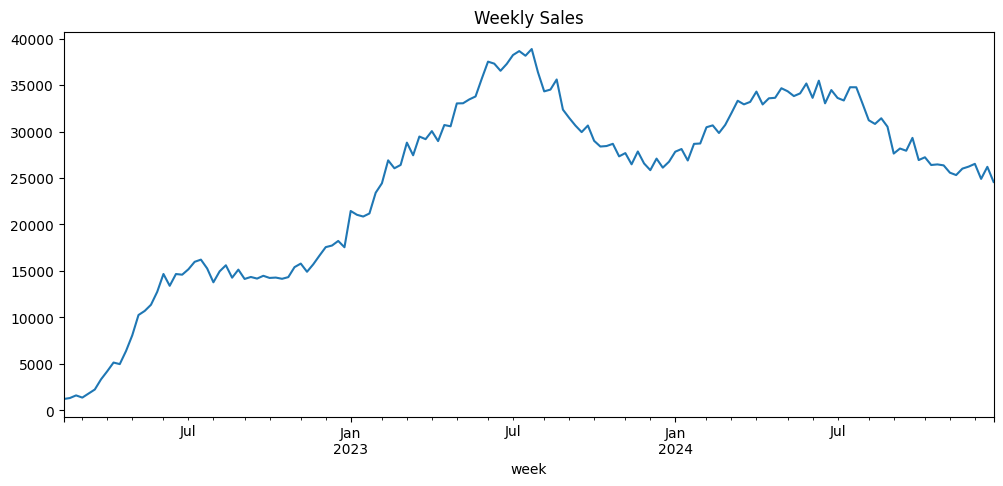

In [72]:
weekly_sales.plot(figsize=(12, 5))
plt.title("Weekly Sales")
plt.show()

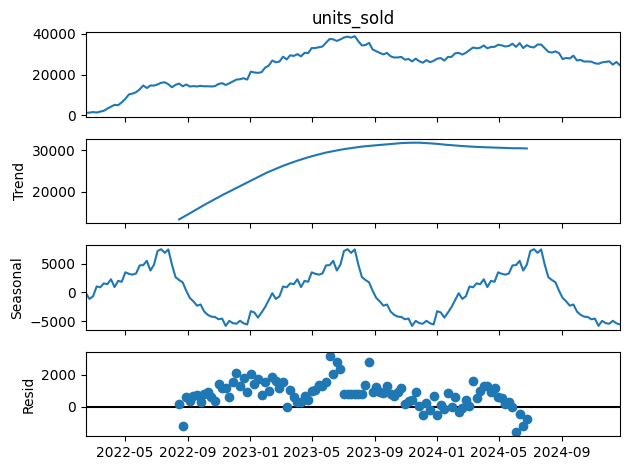

In [73]:
decomp = seasonal_decompose(
    weekly_sales,
    model="additive",
    period=52
)

decomp.plot()
plt.show()

In [74]:
train = weekly_sales.iloc[:-26]
test = weekly_sales.iloc[-26:]

In [75]:
print(train.shape)
print(test.shape)

(124,)
(26,)


In [76]:
naive_fc = np.repeat(train.iloc[-1], len(test))

In [77]:
seasonal_naive_fc = train.iloc[-52:-26].values

In [78]:
def evaluate(actual, forecast):
    mae = mean_absolute_error(actual, forecast)
    rmse = np.sqrt(mean_squared_error(actual, forecast))
    return mae, rmse

In [79]:
print("Naive:", evaluate(test, naive_fc))
print("Seasonal Naive:", evaluate(test, seasonal_naive_fc))

Naive: (5848.653846153846, np.float64(6608.10031179682))
Seasonal Naive: (2397.269230769231, np.float64(2740.0560564170382))


In [80]:
ses = SimpleExpSmoothing(train, initialization_method = "estimated").fit(optimized=True)
ses_fc = ses.forecast(len(test))

evaluate(test, ses_fc)

(5774.711482981802, np.float64(6531.504186638148))

In [81]:
holt = Holt(
    train,
    initialization_method="estimated"
).fit(optimized=True)

holt_fc = holt.forecast(len(test))

evaluate(test, holt_fc)

(4457.9508669112, np.float64(5023.169918324396))

In [82]:
damped = Holt(
    train,
    damped_trend=True,
    initialization_method="estimated"
).fit(optimized=True)

damped_fc = damped.forecast(len(test))

evaluate(test, damped_fc)

(5023.377557226181, np.float64(5702.743008018379))

In [84]:
hw_add = ExponentialSmoothing(
    train,
    trend="add",
    seasonal="add",
    seasonal_periods=52,
    initialization_method="estimated"
).fit(optimized=True)

hw_add_fc = hw_add.forecast(len(test))

evaluate(test, hw_add_fc)

(6453.287312825821, np.float64(7185.539880710202))

In [85]:
hw_mul = ExponentialSmoothing(
    train,
    trend="add",
    seasonal="mul",
    seasonal_periods=52,
    initialization_method="estimated"
).fit(optimized=True)

hw_mul_fc = hw_mul.forecast(len(test))

evaluate(test, hw_mul_fc)

/usr/local/lib/python3.13/dist-packages/statsmodels/tsa/holtwinters/model.py:1065: ConvergenceWarning: Optimization failed to converge. Check mle_retvals.
  res = self._optimize_parameters(res, use_brute, method, minimize_kwargs)


(1960.2161252636668, np.float64(2169.61046361642))

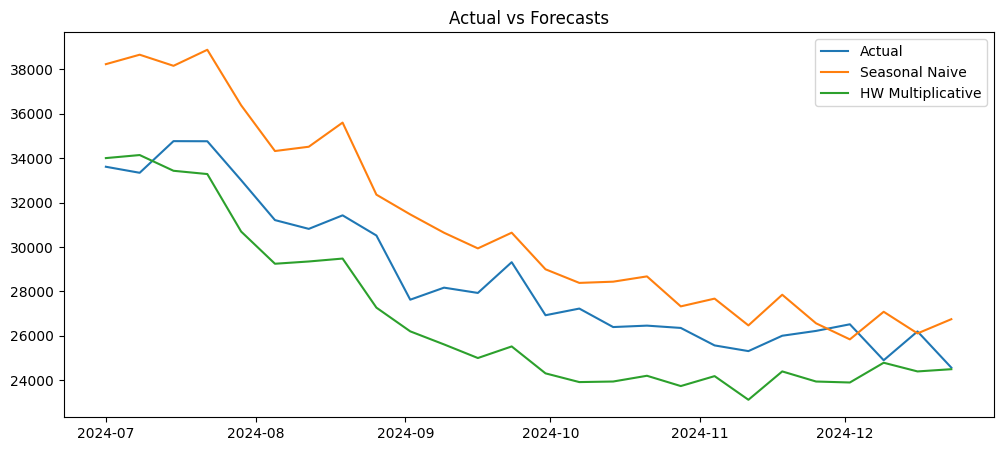

In [86]:
plt.figure(figsize=(12, 5))

plt.plot(test.index, test, label="Actual")
plt.plot(test.index, seasonal_naive_fc, label="Seasonal Naive")
plt.plot(test.index, hw_mul_fc, label="HW Multiplicative")

plt.legend()
plt.title("Actual vs Forecasts")
plt.show()

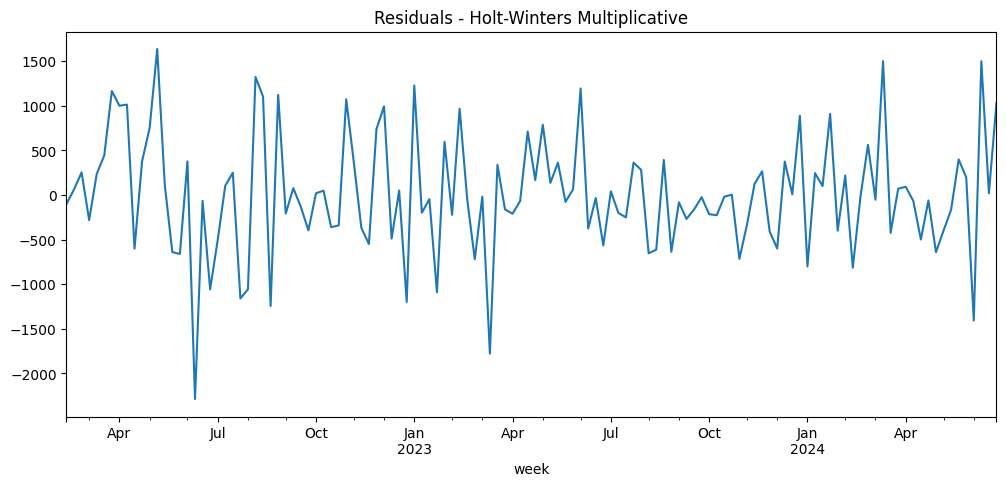

In [87]:
residuals = hw_mul.resid

residuals.plot(figsize=(12, 5))
plt.title("Residuals - Holt-Winters Multiplicative")
plt.show()

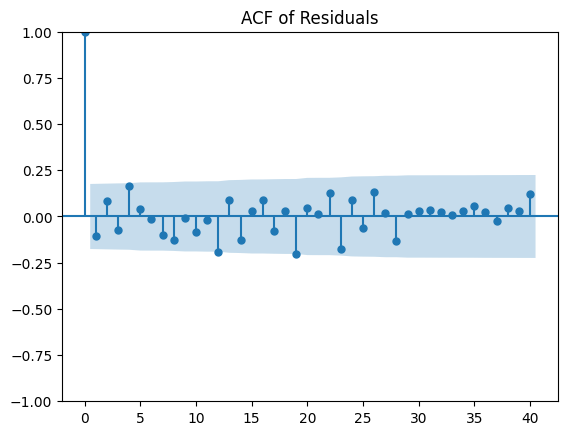

In [88]:
from statsmodels.graphics.tsaplots import plot_acf

plot_acf(residuals.dropna(), lags=40)
plt.title("ACF of Residuals")
plt.show()

In [89]:
from statsmodels.stats.diagnostic import acorr_ljungbox

lb_test = acorr_ljungbox(
    residuals.dropna(),
    lags=[10, 20],
    return_df=True
)

lb_test

,lb_stat,lb_pvalue
10,11.244485,0.33879
20,28.717134,0.09348


Residual diagnostics: Residuals fluctuate around zero with no obvious pattern. Most ACF values fall within the confidence bounds. Ljung–Box p-values at lags 10 and 20 are greater than 0.05, indicating no statistically significant evidence of residual autocorrelation.

In [91]:
final_model = ExponentialSmoothing(
    weekly_sales,
    trend="add",
    seasonal="mul",
    seasonal_periods=52,
    initialization_method="estimated"
).fit(optimized=True)

In [92]:
future_forecast = final_model.forecast(26)

future_forecast

,0
2024-12-30,27339.348766
2025-01-06,26962.542875
2025-01-13,25766.344283
2025-01-20,26617.002916
2025-01-27,27281.654208
2025-02-03,28363.375136
2025-02-10,29214.523149
2025-02-17,27992.673053
2025-02-24,28226.328633
2025-03-03,29591.655381


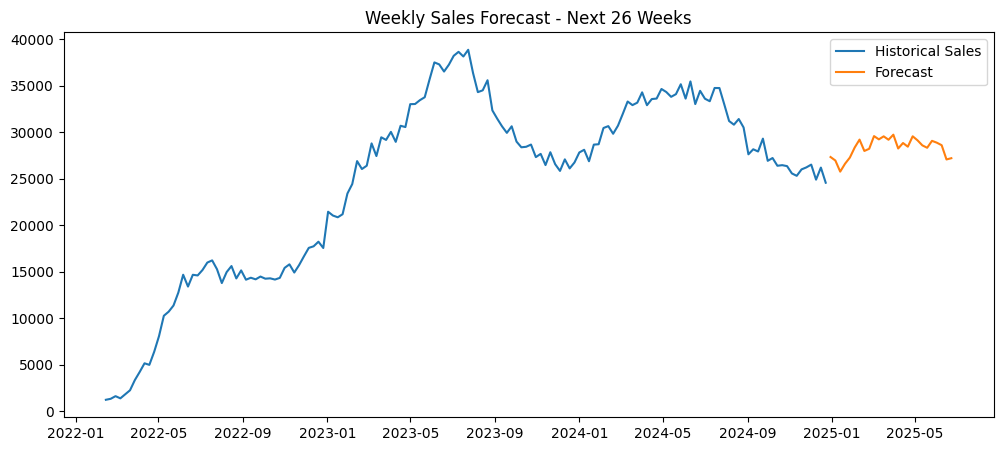

In [93]:
plt.figure(figsize=(12, 5))

plt.plot(weekly_sales.index, weekly_sales, label="Historical Sales")
plt.plot(future_forecast.index, future_forecast, label="Forecast")

plt.legend()
plt.title("Weekly Sales Forecast - Next 26 Weeks")
plt.show()